# A.3 Red List Index

In [1]:
import datetime
now = datetime.datetime.now()
print(f"Última actualización de este notebook: {now.strftime('%d-%m-%Y %H:%M')}")

Última actualización de este notebook: 23-04-2026 14:29


El Indicador de Cabecera A.3, conocido como Índice de la Lista Roja (RLI, por sus siglas en inglés), sintetiza las tendencias en el riesgo promedio de extinción de un conjunto de especies a lo largo del tiempo. Este indicador es fundamental dentro del Marco de Monitoreo del Marco Mundial de Biodiversidad de Kunming-Montreal (CBD), ya que permite evaluar de forma cuantitativa el Objetivo A (mantener y mejorar la resiliencia de los ecosistemas y detener la extinción inducida por actividades humanas) y la Meta 4 (implementar acciones urgentes para recuperar especies amenazadas). El índice se expresa en una escala de 0 a 1, donde un valor de 1 indica que todas las especies evaluadas se encuentran en la categoría de "Preocupación Menor" (riesgo mínimo de extinción), y un valor de 0 indica que todas las especies han colapsado o están clasificadas como "Extintas". Una disminución sostenida del valor del RLI en el tiempo evidencia un deterioro en el estado de conservación y un aumento del riesgo promedio de extinción de la biodiversidad nacional.
Los metadatos oficiales del indicador se encuentran disponibles [aquí](https://www.gbf-indicators.org/metadata/headline/A-3).

## Metodología

La estimación del RLI para Chile se realizó siguiendo la guía metodológica oficial del CBD. El cálculo se basa en la asignación de pesos ordinales (W) a las categorías de conservación, reflejando un gradiente creciente de amenaza: Preocupación menor (LC) = 0; Casi amenazada (NT) = 1; Vulnerable (VU) = 2; En peligro (EN) = 3; En peligro crítico (CR) = 4; Extinta / Extinta en estado silvestre (EX/EW) = 5. Las especies con "Datos insuficientes" (DD) tienen un peso base de 0, pero reciben un tratamiento estadístico especial.
Para un conjunto de N especies, se calcula el riesgo agregado (Rt) sumando los pesos de todas las especies en un año determinado. El riesgo máximo posible (Rmax) se define asumiendo el peor escenario, donde todas las especies evaluadas estarían extintas (Nx5). Finalmente, el RLI se calcula mediante la fórmula: RLI t = 1 - (Rt / Rmax).

## Fuentes de Datos Utilizadas

Para el cálculo del RLI nacional, se utilizaron los datos consolidados del Reglamento de Clasificación de Especies (RCE) del Ministerio del Medio Ambiente, abarcando desde el 1º hasta el 19º Proceso de Clasificación. El RCE constituye la nómina oficial del Estado de Chile y la principal referencia normativa para la gestión ambiental. El uso de esta base nacional, homologada a las categorías globales de la UICN, prioriza la pertinencia territorial del dato asegurando al mismo tiempo la coherencia metodológica internacional exigida por el Marco Mundial. La funete de datos se encuentra en el siguete enlace [https://clasificacionespecies.mma.gob.cl/](https://clasificacionespecies.mma.gob.cl/). 

In [2]:
URL = "https://clasificacionespecies.mma.gob.cl/wp-content/uploads/2026/03/NominaDeEspecies_SegunEstadoConservacion-Chile_actualizado_20mProcesoRCE_5marzo2026.xlsx"

In [3]:
import io
import re
from datetime import datetime

import numpy as np
import pandas as pd
import requests

# -------------------------
# Configuración / constantes
# -------------------------

#SHEET_ID = "1mBKnm0gjecNJcjhzf4rlXfdAi8LAy9Ly"
SHEET_NAME = "Especies"

#URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

source_year_map = {
    "Bol_47": 1998,
    "CAZA": 1998,
    "L_Rojo_Flora": 1989,
    "L_Rojo_Vert": 1989,
    "Núñez et al. 1997": 1997,
    "Yáñez et al. 1997": 1997,
}

weight_category_map = {
    "LC": 0,
    "DD": 0,
    "R": 0,
    "NT": 1,
    "VU": 2,
    "EN": 3,
    "CR": 4,
    "EX": 5,
    "EW": 5,
}

w_max = 5  # Peso máximo para el cálculo del RLI


# -------------------------
# Funciones auxiliares
# -------------------------

def get_year_from_source(value):
    """Obtiene un año desde la fuente de categoría:
    1) Usa el mapa source_year_map si calza algún código.
    2) Si no, extrae el primer año (4 dígitos) del texto.
    3) Si nada aplica, devuelve pd.NA.
    """
    if pd.isna(value):
        return pd.NA

    s = str(value)

    # 1) Revisar el mapeo explícito
    for key, year in source_year_map.items():
        if key in s:
            return year

    # 2) Extraer año por regex
    match = re.search(r"(\d{4})", s)
    if match:
        return int(match.group(1))

    # 3) Nada encontrado
    return pd.NA


def extract_code(value):
    """Extrae el mejor código de categoría (LC, NT, VU, EN, etc.)
    a partir de un texto. Si no encuentra nada, devuelve None.
    """
    if pd.isna(value):
        return None

    s = str(value).upper()
    codes = re.findall(r"\b(LC|DD|R|NT|VU|EN|CR|EX|EW)\b", s)
    if not codes:
        return None

    # Elige el código de mayor peso según weight_category_map
    best = max(codes, key=lambda c: weight_category_map.get(c, -1))
    return best


def build_progressive(df: pd.DataFrame, year_col: str) -> pd.DataFrame:
    """Construye la progresión acumulativa de especies año a año,
    a partir de la columna year_col. Rellena todos los años desde
    el primer año observado hasta el año actual.
    """
    df_tmp = df.copy()

    if year_col not in df_tmp.columns:
        raise KeyError(f"La columna '{year_col}' no existe en el DataFrame.")

    # Crear columna auxiliar 'year' para la progresión
    df_tmp["year"] = df_tmp[year_col]

    # Ordenar
    df_tmp = df_tmp.sort_values(["year", "scientific_name"])
    valid_years = df_tmp["year"].dropna().astype(int)

    if valid_years.empty:
        # No hay años válidos
        return df_tmp.iloc[0:0].copy()

    start_year = int(valid_years.min())
    end_year = datetime.now().year
    years = list(range(start_year, end_year + 1))

    results = []

    # Año inicial
    year_initial = years[0]
    df_prev = df_tmp[df_tmp["year"] == year_initial].copy()
    results.append(df_prev)

    # Progresión
    for year in years[1:]:
        df_actual = df_tmp[df_tmp["year"] == year].copy()
        especies_actuales = set(df_actual["scientific_name"])

        # Especies que estaban antes pero no aparecen este año
        faltantes = df_prev[~df_prev["scientific_name"].isin(especies_actuales)].copy()
        faltantes["year"] = year

        # Unir nuevas + arrastradas
        df_year_full = pd.concat([df_actual, faltantes], ignore_index=True)
        results.append(df_year_full)
        df_prev = df_year_full

    df_cumulativo = pd.concat(results, ignore_index=True)
    df_cumulativo = df_cumulativo.sort_values(["year", "scientific_name"])
    return df_cumulativo


def compute_rli(group: pd.DataFrame) -> pd.Series:
    """Calcula el RLI sobre un grupo de filas (año, o global)."""
    N = len(group)
    sum_w = group["weight_category"].sum()
    rli = 1 - (sum_w / (N * w_max)) if N > 0 else np.nan
    return pd.Series(
        {
            "n_especies": N,
            "suma_pesos": sum_w,
            "RLI": rli,
        }
    )


# -------------------------
# Descarga y preparación del DataFrame
# -------------------------

resp = requests.get(URL)
resp.raise_for_status()

df = pd.read_excel(
    io.BytesIO(resp.content),
    sheet_name=SHEET_NAME,
)

# Año actual desde el decreto vigente
df["ref_decreto"] = df["REFERENCIA o DECRETO\nCategoría Vigente"]
df["year_current"] = (
    df["ref_decreto"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .astype("Int64")
)

# Renombrar columnas largas a nombres manejables
old_name = [c for c in df.columns if c.startswith("Categoría ANTE ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "preview_category_rce_0"})

old_name = [c for c in df.columns if c.startswith("Fuente Categoría  ANTE ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "source_preview_category_rce_0"})

df["year_source_preview_category_rce_0"] = (
    df["source_preview_category_rce_0"]
    .apply(get_year_from_source)
    .astype("Int64")
)

old_name = [c for c in df.columns if c.startswith("Categoría ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "preview_category_rce_1"})

old_name = [c for c in df.columns if c.startswith("Fuente Categoría ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "source_preview_category_rce_1"})

df["year_source_preview_category_rce_1"] = (
    df["source_preview_category_rce_1"]
    .apply(get_year_from_source)
    .astype("Int64")
)

old_name = [c for c in df.columns if "CATEGORÍA VIGENTE" in c][0]
df = df.rename(columns={old_name: "current_category"})

df = df.rename(
    columns={
        "NOMBRE CIENTÍFICO": "scientific_name",
        "REINO": "kingdom",
    }
)


# -------------------------
# Progresión por etapas (0, 1, vigente)
# -------------------------
# -------------------------
# df_cumulativo_0
# -------------------------
df_cumulativo_0 = build_progressive(df, "year_source_preview_category_rce_0")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_0["category_code"] = df_cumulativo_0["preview_category_rce_0"].apply(extract_code)
# Excluir DD y R
df_cumulativo_0 = df_cumulativo_0[~df_cumulativo_0["category_code"].isin(["DD", "R"])]
df_cumulativo_0["weight_category"] = df_cumulativo_0["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_0 = df_cumulativo_0.dropna(subset=["category_code", "weight_category"])
# -------------------------
# df_cumulativo_1
# -------------------------
df_cumulativo_1 = build_progressive(df, "year_source_preview_category_rce_1")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_1["category_code"] = df_cumulativo_1["preview_category_rce_1"].apply(extract_code)
# Excluir DD y R
df_cumulativo_1 = df_cumulativo_1[~df_cumulativo_1["category_code"].isin(["DD", "R"])]
df_cumulativo_1["weight_category"] = df_cumulativo_1["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_1 = df_cumulativo_1.dropna(subset=["category_code", "weight_category"])
# -------------------------
# df_cumulativo_vigente
# -------------------------
df_cumulativo_vigente = build_progressive(df, "year_current")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_vigente["category_code"] = df_cumulativo_vigente["current_category"].apply(extract_code)
# Excluir DD y R
df_cumulativo_vigente = df_cumulativo_vigente[~df_cumulativo_vigente["category_code"].isin(["DD", "R"])]
df_cumulativo_vigente["weight_category"] = df_cumulativo_vigente["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_vigente = df_cumulativo_vigente.dropna(subset=["category_code", "weight_category"])
# Marcar la etapa (para luego "pisar" los registros)
df_cumulativo_0["stage"] = 0
df_cumulativo_1["stage"] = 1
df_cumulativo_vigente["stage"] = 2

# Unir y hacer que etapas más recientes reemplacen a las antiguas
df_cumulativo = pd.concat(
    [df_cumulativo_0, df_cumulativo_1, df_cumulativo_vigente],
    ignore_index=True,
)

df_cumulativo = df_cumulativo.sort_values(["scientific_name", "year", "stage"])

df_cumulativo = (
    df_cumulativo
    .drop_duplicates(subset=["scientific_name", "year"], keep="last")
    .sort_values(["year", "scientific_name"])
    .reset_index(drop=True)
)

# Si quisieras eliminar un año problemático (ej. 1998):
# df_cumulativo = df_cumulativo[df_cumulativo["year"] != 1998]

# -------------------------
# Cálculo del RLI
# -------------------------

rli_global = compute_rli(df_cumulativo)
print("RLI global:")
print(rli_global)

rli_year = (
    df_cumulativo
    .groupby("year")
    .apply(compute_rli)
    .reset_index()
    .sort_values("year")
)

print("\nRLI por año:")
print(rli_year)


RLI global:
n_especies    23491.000000
suma_pesos    52017.000000
RLI               0.557133
dtype: float64

RLI por año:
    year  n_especies  suma_pesos       RLI
0   1997        28.0        71.0  0.492857
1   1998       348.0       837.0  0.518966
2   1999       348.0       837.0  0.518966
3   2000       348.0       837.0  0.518966
4   2001       348.0       837.0  0.518966
5   2002       348.0       837.0  0.518966
6   2003       348.0       837.0  0.518966
7   2004       348.0       837.0  0.518966
8   2005       348.0       837.0  0.518966
9   2006       348.0       837.0  0.518966
10  2007       361.0       880.0  0.512465
11  2008       431.0      1065.0  0.505800
12  2009       482.0      1228.0  0.490456
13  2010       482.0      1228.0  0.490456
14  2011       701.0      1825.0  0.479315
15  2012       744.0      1846.0  0.503763
16  2013       832.0      1946.0  0.532212
17  2014       882.0      2039.0  0.537642
18  2015       968.0      2201.0  0.545248
19  2016      1029

## Resultados

Tendencia General: El RLI nacional mostró un descenso sostenido desde el año 2007 hasta el año 2011, indicando un aumento generalizado en el riesgo promedio de extinción del conjunto de especies evaluadas. Posteriormente presentó un aumento hasta el año 2011, desde cuando se ha mantenido estable hasta el último año reportado, la mediana del índice general se sitúa en torno a 0.6 reflejando que una proporción significativa de la biota clasificada enfrenta algún grado de amenaza (Figura 1).


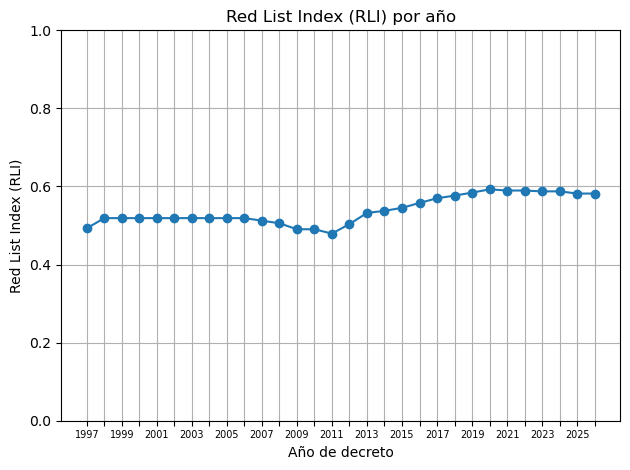

In [11]:

import matplotlib.pyplot as plt
rli_year = rli_year.sort_values("year")
rli_clean = rli_year.copy()
rli_clean = rli_clean.dropna(subset=["year", "RLI"])
rli_clean["year"] = rli_clean["year"].astype(int)
rli_clean["RLI"] = rli_clean["RLI"].astype(float)
fig, ax = plt.subplots()

ax.plot(
    rli_clean["year"],
    rli_clean["RLI"],
    marker="o"
)

ax.set_xlabel("Año de decreto")
ax.set_xticks(rli_clean["year"])
ax.tick_params(axis="x", labelsize=7)
years = rli_clean["year"].values
ticks = years[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)
ax.set_ylabel("Red List Index (RLI)")
ax.set_title("Red List Index (RLI) por año")
ax.set_ylim(0, 1)
ax.set_xticks(rli_clean["year"])
ax.grid(True)
plt.tight_layout()
plt.show()

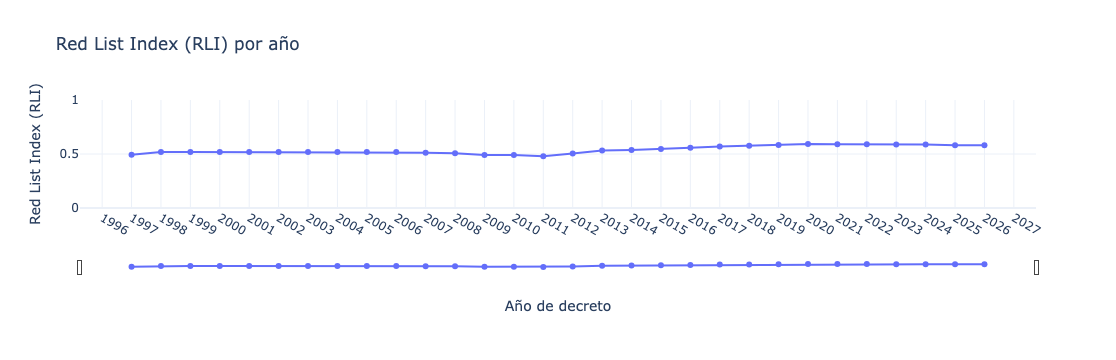

In [16]:
import pandas as pd
import plotly.express as px

# Limpieza
rli_clean = (
    rli_year.sort_values("year")
    .dropna(subset=["year", "RLI"])
    .copy()
)

rli_clean["year"] = rli_clean["year"].astype(int)
rli_clean["RLI"] = rli_clean["RLI"].astype(float)

# Gráfico
fig = px.line(
    rli_clean,
    x="year",
    y="RLI",
    markers=True,
    title="Red List Index (RLI) por año",
    labels={
        "year": "Año de decreto",
        "RLI": "Red List Index (RLI)"
    }
)

fig.update_traces(
    mode="lines+markers",
    hovertemplate="Año: %{x}<br>RLI: %{y:.4f}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    yaxis=dict(range=[0, 1]),
    xaxis=dict(
        title="Año de decreto",
        tickmode="linear",
        dtick=1,
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=5, label="5 años", step="year", stepmode="backward"),
                dict(count=10, label="10 años", step="year", stepmode="backward"),
                dict(step="all", label="Todos")
            ]
        )
    )
)

fig.show()

Figura 1. Red List Index (RLI). Tendencia general (1997- 2025).
### Desagregación Taxonómica: 
Reino Plantae (669 especies evaluadas): Es el grupo que presenta el mayor riesgo de extinción relativo en la actualidad. Su índice RLI inició en 0,528 (año 1998) y ha mostrado un leve declive y posterior estancamiento, situándose en 0,523 para el año 2026 (Figura 2).
Reino Animalia (699 especies evaluadas): A diferencia de las plantas, la curva de los animales muestra un incremento numérico en su índice a lo largo de las décadas. Partiendo de un RLI de 0,492 en 1997, el indicador ha subido progresivamente hasta alcanzar un valor de 0,606 en 2026 (Figura 2).
Reino Fungi (125 especies evaluadas): Es el grupo que registra el menor riesgo relativo según la métrica, aunque con una muestra significativamente menor. Su RLI pasó de 0,582 en sus primeras evaluaciones (1998) a un valor de 0,803 para el año 2026 (Figura 2).

In [5]:
rli_year_kingdom = (
    df_cumulativo
    .groupby(["year", "kingdom"])
    .apply(compute_rli)
    .reset_index()
    .sort_values("year")
)

print("\nRLI por reino y año:")
print(rli_year_kingdom)


RLI por reino y año:
    year   kingdom  n_especies  suma_pesos       RLI
0   1997  Animalia        28.0        71.0  0.492857
1   1998  Animalia       171.0       426.0  0.501754
2   1998     Fungi        23.0        48.0  0.582609
3   1998   Plantae       154.0       363.0  0.528571
4   1999  Animalia       171.0       426.0  0.501754
..   ...       ...         ...         ...       ...
82  2025  Animalia       718.0      1419.0  0.604735
84  2025   Plantae       691.0      1667.0  0.517511
86  2026     Fungi       126.0       123.0  0.804762
85  2026  Animalia       718.0      1419.0  0.604735
87  2026   Plantae       691.0      1667.0  0.517511

[88 rows x 5 columns]


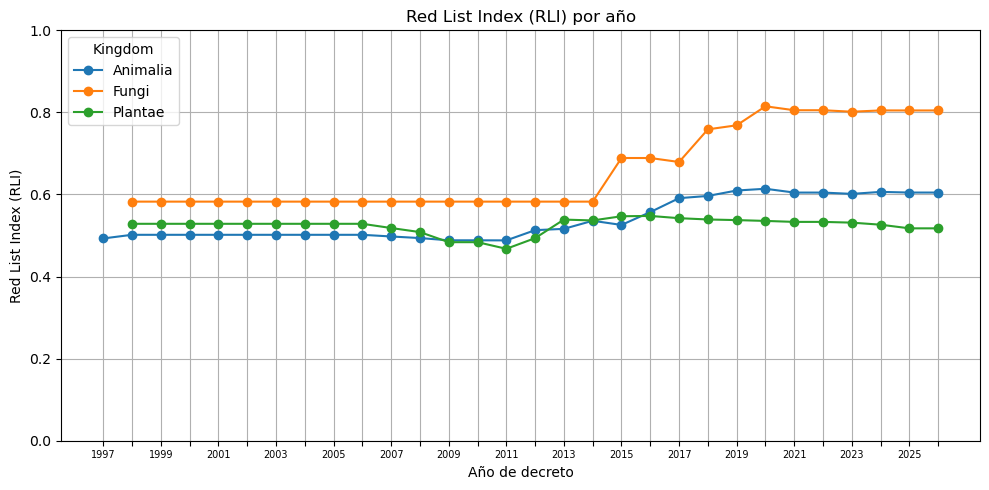

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for kingdom, group in rli_year_kingdom.groupby("kingdom"):
    ax.plot(
        group["year"],
        group["RLI"],
        marker="o",
        label=kingdom,
    )

ax.legend(title="Kingdom")
ax.set_xlabel("Año de decreto")
ax.set_xticks(rli_clean["year"])
ax.tick_params(axis="x", labelsize=7)
years = rli_clean["year"].values
ticks = years[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)
ax.set_ylabel("Red List Index (RLI)")
ax.set_title("Red List Index (RLI) por año")
ax.set_ylim(0, 1)
ax.set_xticks(rli_clean["year"])
ax.grid(True)

plt.tight_layout()
plt.show()




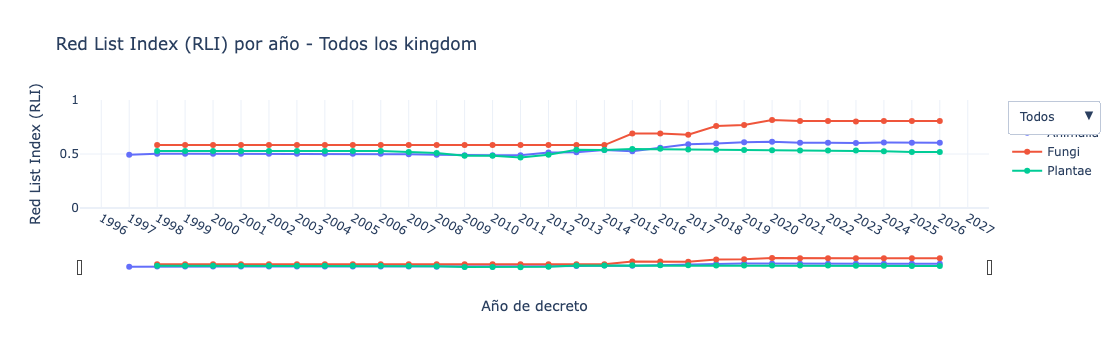

In [17]:
import pandas as pd
import plotly.graph_objects as go

# Limpieza
rli_kingdom_clean = (
    rli_year_kingdom
    .dropna(subset=["year", "RLI", "kingdom"])
    .copy()
)

rli_kingdom_clean["year"] = rli_kingdom_clean["year"].astype(int)
rli_kingdom_clean["RLI"] = rli_kingdom_clean["RLI"].astype(float)
rli_kingdom_clean["kingdom"] = rli_kingdom_clean["kingdom"].astype(str)

rli_kingdom_clean = rli_kingdom_clean.sort_values(["kingdom", "year"])

kingdoms = sorted(rli_kingdom_clean["kingdom"].unique())

fig = go.Figure()

# Crear una traza por kingdom
for kingdom in kingdoms:
    group = rli_kingdom_clean[rli_kingdom_clean["kingdom"] == kingdom].sort_values("year")
    
    fig.add_trace(go.Scatter(
        x=group["year"],
        y=group["RLI"],
        mode="lines+markers",
        name=kingdom,
        visible=True,
        hovertemplate=(
            f"Kingdom: {kingdom}<br>"
            "Año: %{x}<br>"
            "RLI: %{y:.4f}<extra></extra>"
        )
    ))

# Botones dropdown
buttons = []

# Mostrar todos
buttons.append(
    dict(
        label="Todos",
        method="update",
        args=[
            {"visible": [True] * len(kingdoms)},
            {"title": "Red List Index (RLI) por año - Todos los kingdom"}
        ]
    )
)

# Mostrar uno por uno
for i, kingdom in enumerate(kingdoms):
    visible = [False] * len(kingdoms)
    visible[i] = True
    
    buttons.append(
        dict(
            label=kingdom,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Red List Index (RLI) por año - {kingdom}"}
            ]
        )
    )

fig.update_layout(
    title="Red List Index (RLI) por año - Todos los kingdom",
    xaxis_title="Año de decreto",
    yaxis_title="Red List Index (RLI)",
    yaxis=dict(range=[0, 1]),
    xaxis=dict(
        tickmode="linear",
        dtick=1,
        rangeslider=dict(visible=True)
    ),
    template="plotly_white",
    hovermode="x unified",
    legend_title="Kingdom",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1,
            yanchor="top"
        )
    ]
)

fig.show()

Figura 2. Red List Index (RLI). Desagregación taxonómica (1997 - 2025)


In [7]:
df_cumulativo.to_excel("rli_base.xlsx", index=False)

In [8]:
import pandas as pd

# 1. Filtrar años 2020–2026
rli_total_2018_2024 = (
    rli_clean
    .query("year >= 2018 and year <= 2024")
    [["year", "RLI"]]
    .rename(columns={"RLI": "RLI_total"})
)

rli_kingdom_2018_2024 = (
    rli_year_kingdom
    .query("year >= 2018 and year <= 2024")
)

# 2. Pivotear para tener un reino por columna
rli_kingdom_wide = (
    rli_kingdom_2018_2024
    .pivot(index="year", columns="kingdom", values="RLI")
    .reset_index()
)

# 3. Unir total + reinos
tabla_rli = (
    rli_total_2018_2024
    .merge(rli_kingdom_wide, on="year", how="left")
    .sort_values("year")
)

tabla_rli

/tmp/ipykernel_22135/105843443.py:13: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("year >= 2018 and year <= 2024")


,year,RLI_total,Animalia,Fungi,Plantae
0,2018,0.576614,0.596457,0.758730,0.539130
1,2019,0.584272,0.609677,0.768571,0.537586
2,2020,0.592593,0.613946,0.814894,0.535605
3,2021,0.589691,0.604666,0.805310,0.533223
4,2022,0.589691,0.604666,0.805310,0.533223
5,2023,0.587395,0.601466,0.801681,0.531419
6,2024,0.587644,0.606313,0.804839,0.526380


## Observaciones
La desagregación de los resultados muestra que la flora nacional (Plantae) mantiene un índice cercano a 0,5 durante el periodo evaluado. Por su parte, la curva para animales y hongos presenta una tendencia al alza (acercándose a 1). Sin embargo, este incremento en el valor del índice debe ser interpretado con cautela en el contexto del sistema nacional, ya que metodológicamente no responde de forma exclusiva a una recuperación poblacional en terreno.
## Brechas
El análisis de los resultados revela limitaciones metodológicas en la estructuración de los datos que alimentan el índice:
1. **Sesgo por ingreso de nuevas especies**: La directriz de la UICN establece que el RLI debe variar ante cambios genuinos en el estado de conservación de especies previamente evaluadas. En los registros nacionales, el aumento del índice se explica en gran medida por la incorporación anual de nuevas especies al sistema. Si los taxones ingresados presentan menor riesgo relativo, el promedio ponderado del RLI aumenta, lo que no refleja necesariamente una mejora de las especies ya amenazadas. Para futuros reportes, podría explorarse la viabilidad de aislar los cambios no genuinos o calcular el índice sobre cohortes específicas de especies que cuenten con evaluaciones recurrentes.
2. **Baja frecuencia de reevaluación**: Para que el RLI opere como un indicador de tendencias continuas, las especies requieren ser evaluadas periódicamente. En la actualidad, el sistema nacional ha enfocado parte importante de sus esfuerzos en la clasificación de taxones nuevos para ampliar el catálogo oficial, lo que genera un rezago en la reevaluación sistemática de las especies que ingresaron al proceso normativo en décadas anteriores.
3. **Representatividad taxonómica**: La muestra basal empleada para el cálculo presenta diferencias de cobertura. Mientras el reino Plantae y el reino Animalia agrupan la mayor proporción de las evaluaciones (con cerca de 700 especies cada uno), grupos como el reino Fungi y los invertebrados cuentan con una representación significativamente menor. Esto incide en que el valor final del índice nacional refleje principalmente las trayectorias de conservación de grupos históricamente más estudiados.

In [9]:
import os
import pandas as pd
from sqlalchemy import create_engine, text

# Ejemplo: tu dataframe
# df = pd.DataFrame({...})

# Leer variables de entorno
DB_NAME = os.getenv("SEVENNR_DB_NAME")
DB_USER = os.getenv("SEVENNR_DB_USER")
DB_PASSWORD = os.getenv("SEVENNR_DB_PASSWORD")
DB_HOST = os.getenv("SEVENNR_DB_HOST", "localhost")
DB_PORT = os.getenv("SEVENNR_DB_PORT", "5432")

# Crear conexión SQLAlchemy
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Guardar dataframe en una tabla
rli_year_kingdom.to_sql(
    name="a_3_rli_kingdom",
    con=engine,
    if_exists="replace",   # opciones: 'fail', 'replace', 'append'
    index=False
)

print("DataFrame guardado correctamente en PostgreSQL")

DataFrame guardado correctamente en PostgreSQL


DETAIL:  The database was created using collation version 2.41, but the operating system provides version 2.31.
HINT:  Rebuild all objects in this database that use the default collation and run ALTER DATABASE "7nr" REFRESH COLLATION VERSION, or build PostgreSQL with the right library version.


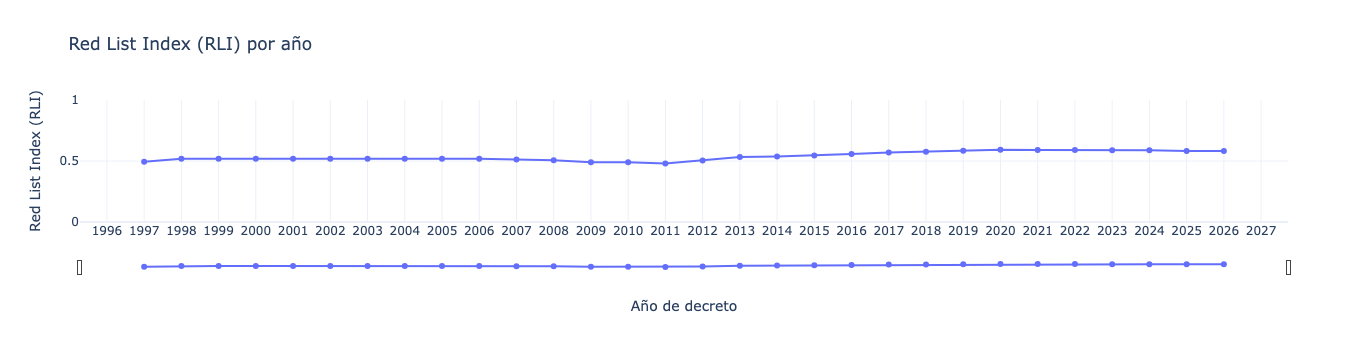